This tutorial explains how fine-tuning Large Language Models (LLMs) works. Specifically, it discusses how you can fine-tune the pre-trained model Gemma 2 ([`gemma-2-2b-jpn-it`](https://huggingface.co/google/gemma-2-2b-jpn-it)) for **converting conventional Japanese text into its [Yomigana/Furigana](https://en.wikipedia.org/wiki/Furigana) (reading aid) representation** to help students improve their Japanese reading skills.

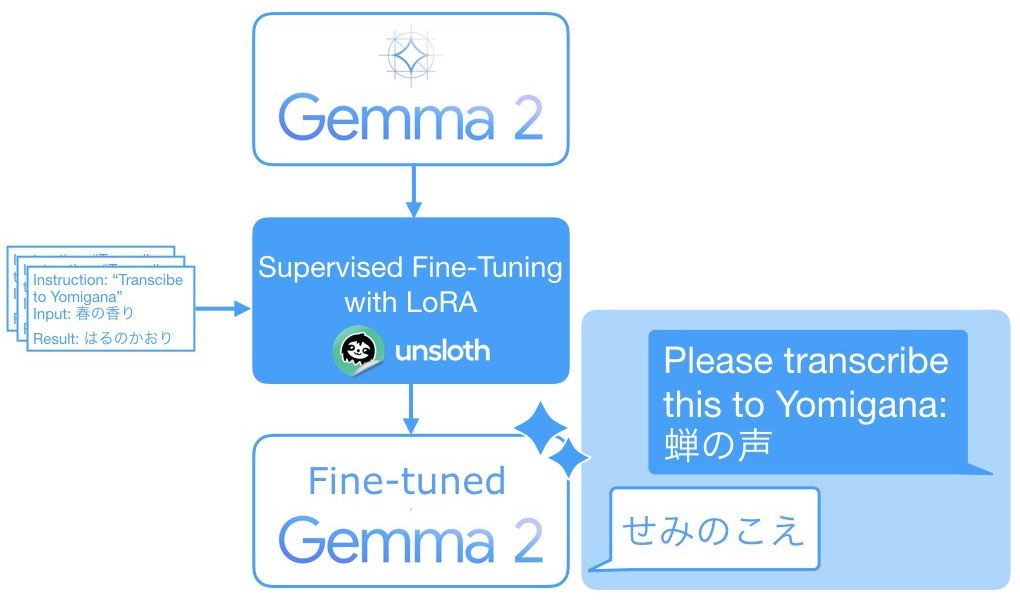

Summary of Highlights:
- **Goal:** Create an efficient and accurate variant of Gemma 2 for **converting Japanese text to Yomigana (reading aid)**.
- **Use Case:** Provide **accessibility** to Japanese language readers and learners by automatically generating Yomigana for Japanese text.
- **Necessity:** Evaluation against other alignment techniques shows that zero-shot (accuracy of 0.0 and BLEU score of 0.30) and few-shot prompting (accuracy of 0.04 and BLEU score of 0.38) are insufficient and that **fine-tuning is necessary to achieve the desired goal**.
- **Fine-tuning Technique:** For fine-tuning Gemma 2, this tutorial uses:
    - A curated and post-processed version of the [Shosi dataset](https://github.com/ndl-lab/huriganacorpus-ndlbib) by [NDL Lab](https://lab.ndl.go.jp/) with a CC-BY-4.0 license.
This dataset includes 16.5 M titles of Japanese books and magazines from a wide range of areas, as well as their corresponding furigana annotations.
    - [Unsloth](https://github.com/unslothai/unsloth) for faster LLM fine-tuning with [Low-Rank Adaptation (LoRA)](https://arxiv.org/abs/2106.09685) within the given computational resources (free Kaggle Notebook environment). 
    - [Weights & Biases (W&B)](https://wandb.ai/) for experiment tracking.
- **Result:** The final fine-tuned [Gemma 2 JPN Yomigana IT](https://www.kaggle.com/models/iamleonie/gemma-2-2b-jpn-yomigana-it) model **outperforms the rule-based MeCab solution** on the used test set of 1,000 samples: 

| Yomigana Solution   | Accuracy | BLEU score |
|----------|----------|------------|
| MeCab    |  0.762   |   0.919    |
| [Gemma 2 JPN Yomigana IT](https://www.kaggle.com/models/iamleonie/gemma-2-2b-jpn-yomigana-it)    |   0.841  |       0.945     |

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Motivation and Use Case Definition

The Japanese alphabet consists of three different alphabets:
- Hiragana (46 basic characters; usually learned in kindergarten)
- Katakana (46 basic characters; usually learned after Hiragana in kindergarten)
- Kanji (2,136 regular-use kanji (Jōyō kanji) and over 50,000 in general; usually learned from the first year of elementary school to the last year of junior high school)

While Hiragana and Katakana are relatively straightforward, Kanji presents significant challenges, such as:
- **The volume of characters and rare Kanji:** Becoming proficient in over 2,000 characters takes many years of studying. On top of that, knowing over 50,000 rare Kanji feels like an impossible task.
- **Varying pronunciations depending on context (Polyphonic Kanji)**: Many Kanji have multiple pronunciations (Kun'yomi and On'yomi) depending on context. Below, you can see an example of three sentences to showcase the pronunciations of 上 (up) and 手 (hand). 
Alone standing the kun'yomi is 'ue' for 上 (up) and 'te' for 手 (hand).
In combination, the on'yomi is 'jyouzu' for 上手  (good).
And if the combination ends with い, then 上手い  (good) is pronounced 'umai'

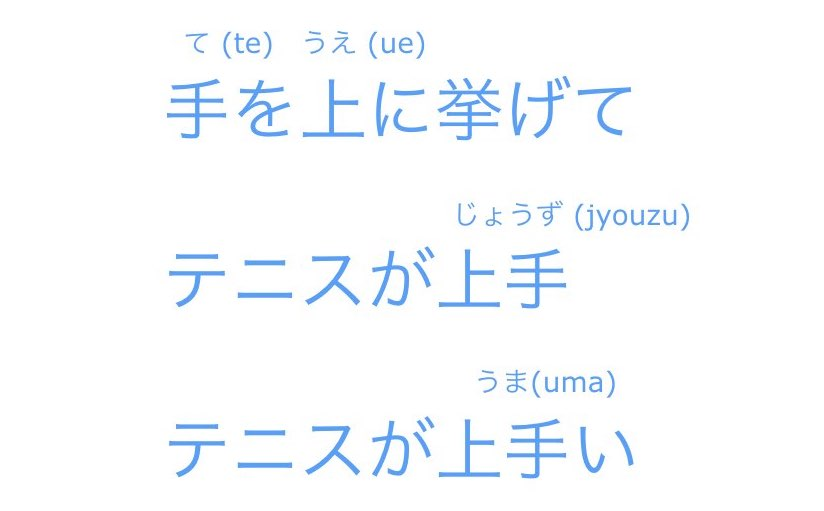

Because of these challenges, reading a text above their proficiency level can be a slow and frustrating process for language learners, young readers, or anyone encountering unfamiliar Kanji. 

To address these challenges, Japanese texts often include **Furigana (or Yomigana)**, smaller kana characters placed alongside Kanji to indicate pronunciation. Furigana is commonly found in educational materials for children or beginners and in general texts to assist with rare or complex Kanji.

Already available **rule-based tools** for Yomigana generation, such as [MeCab](https://pypi.org/project/mecab-python3/), have been reported to achieve accuracies as high as 97% [3] but suffer from inherent limitations:
- Lack of context awareness: Making accurate Furigana generation for polyphonic Kanji is non-trivial. Rule-based systems often fail to interpret delicate nuances accurately, as they rely on static dictionaries and predefined rules.
- Limitations of dictionaries: Characters not frequently used or outside the Jōyō kanji list are often not covered adequately in rule-based dictionaries.

LLMs have the potential to surpass rule-based tools for generating appropriate Yomigana for complex or rare Kanji because they offer significant advantages over them. First, LLMs can interpret the context of a sentence, enabling accurate disambiguation of polyphonic Kanji. Second, being trained on vast amounts of data allows LLMs to be aware of more rare Kanji than static rule-based solutions.

Thus, this **project aims to fine-tune the pre-trained model Gemma 2 to generate  Yomigana for Japanese text** to assist Japanese language learners and readers who struggle with advanced or rare Kanji.

# How to evaluate an LLM for Yomigana Transcription

To check if we need to fine-tune the model, we will first discuss how to evaluate the pre-trained model's performace on our use case. Then we will evaluate the pre-trained model's performance on zero-shot and few-shot prompting to check if there's any need to fine-tune the model for the intended downstream task.

<div class="alert alert-block alert-info">
    <h3>When (and why) to fine-tune an LLM</h3>
    Fine-tuning can be helpful when other LLM alignment techniques, such as prompt engineering (e.g., few-shot prompting) or Retrieval-Augmented Generation (RAG), are not achieving sufficient results. Therefore, it is recommended to check if fine-tuning is actually necessary before investing time building a fine-tuning pipeline. To check if fine-tuning is necessary, you can evaluate the performance of the pre-trained LLM with different alignment techniques.
</div>

Evaluating an LLM's performance is usually not an easy task because the LLM's generations are open-ended, meaning that there's more than one correct answer. This makes it impossible to evaluate against a ground truth label. That's why LLM generations are often manually evaluated by humans. While this approach results in the most meaningful score, it is not scalable. A newly emerging field of research is to evaluate the LLM's output with another LLM. This technique is called [LLMs-as-a-judge](https://arxiv.org/abs/2411.15594).

Luckily, evaluating the LLM's performance on transcribing common Japanese text into Yomigana text is more straightforward because we can evaluate it against a ground truth label. For this use case, we evaluate the model's performance using two different metrics: **Accuracy** and **BLEU score**.

The **accuracy** score simply calculates how many generations exactly match the ground truth label. 

In [ ]:
from sklearn.metrics import accuracy_score

ground_truth = ["わがくにのしゃかい"]
generation_true = ["わがくにのしゃかい"]
generation_slightly_false = ["わがこくのしゃかい"]
generation_completely_false = ["わが国の社会"]

accuracy_true = accuracy_score(ground_truth, generation_true)
print(f"Accuracy for correct generation {generation_true}: {accuracy_true:.2f}")

accuracy_slightly_false = accuracy_score(ground_truth, generation_slightly_false)
print(f"Accuracy for slightly wrong generation {generation_slightly_false}: {accuracy_slightly_false:.2f}")

accuracy_completely_false = accuracy_score(ground_truth, generation_completely_false)
print(f"Accuracy for completely wrong generation {generation_completely_false}: {accuracy_completely_false:.2f}")

The **[BLEU (BiLingual Evaluation Understudy) score](https://en.wikipedia.org/wiki/BLEU)** on the other hand, gives a little bit more nuance to the quality of the generation. The disadvantage of the accuracy score is that it is very black and white: The answer is either an exact match or not.  As you can see above, the accuracy score is the same for the slightly wrong and the completely wrong generations.

The BLEU score, however, considers the quality of the generations' correspondence to the ground truth labels by leveraging n-gram matches. This metric is often used in machine translations. As you can see below, the BLEU score is higher for the slightly wrong generation and lower for the completely wrong generation. 

Note: Usually, you'd need an appropriate tokenizer to slight the generation into appropriate tokens for the n-grams. However, since we are evaluating on a character level, we can split the generations by using `list()` instead of a tokenizer.

In [ ]:
from nltk.translate.bleu_score import sentence_bleu

ground_truth = "わがくにのしゃかい"
generation_true = "わがくにのしゃかい"
generation_slightly_false = "わがこくのしゃかい"
generation_completely_false = "わが国の社会"

bleu_true = sentence_bleu([list(ground_truth)], list(generation_true))
print(f"BLEU score for correct generation {generation_true}: {bleu_true:.2f}")

bleu_slightly_false = sentence_bleu([list(ground_truth)], list(generation_slightly_false))
print(f"BLEU score for slightly wrong generation {generation_slightly_false}: {bleu_slightly_false:.2f}")

bleu_completely_false = sentence_bleu([list(ground_truth)], list(generation_completely_false))
print(f"BLEU score for completely wrong generation {generation_completely_false}: {bleu_completely_false:.2f}")

By leveraging the accuracy and the BLEU score, we can evaluate how many of the generations are exact matches and how the quality of the overall generations is (e.g., is it not transcribing any Kanji to Hiragana or are just some parts of the transcription wrong?).

*Note: To reduce the computational load on this notebook, the actual calculation of the following evaluations are moved to an [evaluation notebook](https://www.kaggle.com/code/iamleonie/evaluating-gemma-2-jpn-for-yomigana-generation). Please see it for implementation details.* 

The pre-trained LLM is evaluated on a **zero-shot prompt template** as shown below:

```python
alpaca_prompt = """以下は、タスクを説明する指示と、さらに文脈を提供する入力がペアになったものです。リクエストを適切に完了する回答を書いてください。

### 指示:
以下の入力を読み仮名に書き換えてください。

### 入力:
{}

### 回答:
{}"""
```

and a **few-shot prompt template** with some examples as shown below:

```python
alpaca_few_shot_prompt = """以下は、タスクを説明する指示と、さらに文脈を提供する入力がペアになったものです。リクエストを適切に完了する回答を書いてください。

### 指示:
入力を読み仮名に書き換えてください。以下にいくつかの例を示します：

例1) 
入力: 航空MRJが5度目の納期延期で三菱重工が抱く淡い期待
回答: こうくうMRJが5どめののうきえんきでみつびしじゅうこうがだくあわいきたい

例2) 
入力: わが国の社会構造の変化と教育改革の課題
回答: わがくにのしゃかいこうぞうのへんかときょういくかいかくのかだい

例3) 
入力: 深谷市内遺跡。
回答: ふかやしないいせき。

例4) 
入力: 2016年12月及び年間の輸出入(韓国関税庁)
回答: 2016ねん12がつおよびねんかんのゆしゅつにゅう(かんこくかんぜいちょう)

例5) 
入力: 解体シナリオもはや再建は不可能原発ビジネスから撤退
回答: かいたいしなりおもはやさいけんはふかのうげんぱつびじねすからてったい

以下の入力を読み仮名に書き換えてください。

### 入力:
{}

### 回答:
{}"""
```

Below, you can see the accuracy and BLEU scores of Gemma 2 JPN IT for generating Yomigana for a test dataset of 1,000 samples. As reference points, we have benchmarked a rule-based tool called MeCab on the test dataset and determined baseline scores of the original common Japanese texts as outputs (e.g., we input "わが国の社会" and get "わが国の社会" as an output - meaning no transcription to Yomigana at all).

In [ ]:
import numpy as np
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def evaluate_model_performance(df):
    accuracy = accuracy_score(df['Yomigana'], df['generated_text'])
    bleu_mean = df['bleu'].mean()

    return [accuracy, bleu_mean]
    
df_mecab = pd.read_csv('/kaggle/input/evaluating-gemma-2-jpn-for-yomigana-generation/mecab_benchmark.csv')
[mecab_accuracy, mecab_bleu] = evaluate_model_performance(df_mecab)

metrics = []
df_zero_shot = pd.read_csv('/kaggle/input/evaluating-gemma-2-jpn-for-yomigana-generation/zero-shot.csv')
df_zero_shot.fillna('', inplace=True)
metrics.append(evaluate_model_performance(df_zero_shot))

df_few_shot = pd.read_csv('/kaggle/input/evaluating-gemma-2-jpn-for-yomigana-generation/few-shot.csv')
df_few_shot.fillna('', inplace=True)
metrics.append(evaluate_model_performance(df_few_shot))

# Benchmark BLEU score if the text was not transcribed at all
bleu_baseline = df_zero_shot.apply(lambda x: sentence_bleu([list(x.Yomigana)], list(x.Japanese_text)), axis=1).mean()

# Data
labels = ['Zero-shot prompting', 'Few-shot prompting']

# Parameters for bar plots
x = np.arange(len(labels))  # X positions for groups
width = 0.35  # Width of bars

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Accuracy
bars1 = ax1.bar(x, np.array(metrics)[:,0], width, color='#076EFF', label='Accuracy')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.axhline(y=mecab_accuracy, color='#438EFC', linestyle='--', linewidth=1)  # Horizontal line
ax1.text(-0.2, mecab_accuracy, f'MeCab benchmark ({mecab_accuracy:.2f})', color='#438EFC', fontsize=12, ha='left', va='bottom')  # Annotation

ax1.set_ylim(0, 1)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlabel('Alignment Technique', fontsize=14)
ax1.set_ylabel('Accuracy', fontsize=14)
ax1.set_title('Accuracy\nfor Different Alignment Techniques\n', fontsize=16)
ax1.tick_params(axis='x', labelsize=12)

# Annotate bars with values
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x()+0.2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=12, color='#076EFF')

# Plot 2: BLEU score
bars2 = ax2.bar(x, np.array(metrics)[:,1], width, color='#076EFF')

ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.axhline(y=mecab_bleu, color='#438EFC', linestyle='--', linewidth=1)  # Horizontal line
ax2.text(-0.2, mecab_bleu, f'MeCab benchmark ({mecab_bleu:.2f})', color='#438EFC', fontsize=12, ha='left', va='bottom')  # Annotation

ax2.axhline(y=bleu_baseline, color='#438EFC', linestyle='--', linewidth=1)  # Horizontal line
ax2.text(-0.2, bleu_baseline, f'Baseline ({bleu_baseline:.2f})', color='#438EFC', fontsize=12, ha='left', va='bottom')  # Annotation

ax2.set_ylim(0, 1)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlabel('Alignment Technique', fontsize=14)
ax2.set_ylabel('BLEU score', fontsize=14)
ax2.set_title('BLEU Score\nfor Different Alignment Techniques\n', fontsize=16)
ax2.tick_params(axis='x', labelsize=12)


# Annotate bars with values
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x()+0.2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=12, color='#076EFF')


# Adjust layout and show plot
plt.tight_layout()
plt.show()

del df_mecab, df_zero_shot, df_few_shot

Although we can see that few-shot prompt engineering is more effective than zero-shot prompting at yielding correct Yomigana translations, the results are still far from perfect. The zero-shot prompting performs even worse than the baseline BLEU score for no transcription. Both prompting techniques perform much worse than the already available rule-based MeCab solution.

**Let's fine-tune the pre-trained model and see if we can achieve better results than the rule-based MeCab solution.**

# Building a LLM Fine-Tuning Pipeline using LoRA

Now, let's build a pipeline to fine-tune Gemma 2 to be able to generate corresponding Yomigana to any given Japanese text. For fine-tuning, we apply supervised fine-tuning with an instruction dataset and a [Parameter-Efficient Fine-Tuning (PEFT)](https://huggingface.co/blog/peft) technique called  [Low-Rank Adaptation (LoRA)](https://arxiv.org/abs/2106.09685). 

<div class="alert alert-block alert-info">
    <h3>Methods for fine-tuning LLMs</h3>
    There are many different techniques you can use to fine-tune an LLM.
     <ul>
         <li><strong>Supervised fine-tuning (SFT)</strong>: One way to fine-tune LLMs is with Supervised Fine-Tuning, which is also sometimes called instruction fine-tuning because it uses a smaller dataset of <strong>instructions</strong> and answers. But full fine-tuning LLMs, like Gemma 2, is hard and becomes infeasible on common consumer hardware because they are large (duh). That's why so-called Parameter-Efficient Fine-Tuning (PEFT) techniques are popular.
             
The main goal is to transform a basic model that predicts text into an assistant that can follow specific instructions. This fine-tuning technique can enhance the model’s overall performance, add new knowledge, or adapt it to specific tasks and domains. 

A popular PEFT technique is Low-Rank Adaptation (LoRA), which decomposes the large weight matrix into two smaller low-rank matrices in the attention layers. This heavily reduces the number of trainable parameters that need to be fine-tuned.</li>
         <li><strong>Preference Alignment</strong>: Another technique to align LLMs is preference alignment with e.g., Reinforcement Learning from Human Feedback (RLHF), which uses a reward model and a dataset of instructions and <strong>human preferences</strong> (preferred answer and rejected answer). Preference alignment is usually applied as an optional fine-tuning step after instruction tuning to remove unwanted responses or modify the style.</li>
    </ul>
</div>

The following pipeline uses the [Kaggle Gemma2 9b unsloth notebook](https://www.kaggle.com/code/danielhanchen/kaggle-gemma2-9b-unsloth-notebook
) as a baseline.

## Preparation: Set up development environment

Before we begin, we need to set up the development environment. This notebook is intended to be run on Kaggle or on Google Colab.

In [ ]:
ENVIRONMENT = 'KAGGLE' # or 'COLAB'

if ENVIRONMENT == 'KAGGLE':
    output_dir = '/kaggle/working/'
else: # 'COLAB'
    output_dir = 'content'

### Install required packages
Next, we will install the required packages for fine-tuning with Unsloth (`torch`, `torchvision`, `unsloth`, `accelerate`, `transformers`) and for using the Kaggle Hub for model uploading (`kagglehub`).

Unsloth is a library for faster LLM fine-tuning. It is compatible with the [Hugging Face](https://huggingface.co/) ecosystem and can be used with the trainer suite from its `TRL` library. Unsloth speeds up the fine-tuning process by overwriting parts of the modeling code with optimized operations. [7]

Note: This can take up to 5 minutes to install.

In [ ]:
%%capture
!pip install pip3-autoremove
!pip-autoremove torch torchvision torchaudio -y
!pip install torch torchvision torchaudio xformers --index-url https://download.pytorch.org/whl/cu121
!pip install unsloth
!pip install accelerate
!pip install transformers==4.47.1
!pip install --upgrade kagglehub>=0.3.6

### Accelerator / GPU Requirements
Since Unsloth uses the Triton GPU compiler as the backend, we can only use GPU devices with CUDA Capability >= 7.0. To run this code in a Kaggle Notebook, this means that we can't use the NVIDIA P100 (CUDA capability 6.0) and must use T4 (CUDA capability 7.5). If you want to run this code in Google Colab, you can also use NVIDIA A100.

By using Unsloth and specific training parameters and settings, such as `load_in_4bit = True`, this pipeline doesn't require large computational resources and can be run in a free 16 GB memory GPU, like the T4.

### Request access to Gemma models
To use Gemma, you must request access to the model through Kaggle:
- Sign in or register at [kaggle.com](kaggle.com)
- Open the [Gemma 2 model card](https://www.kaggle.com/models/google/gemma-2) and select "Request Access"
- Complete the consent form and accept the terms and conditions.

### API keys as secrets
To use external services like Hugging Face and W&B, you need to attach your API keys as secrets. For this tutorial, we need the following API keys, which you can obtain as follows:
- **Hugging Face API key** to load the base model from Hugging Face to the fine-tuned (obtain from your Hugging Face profile > "[Access Tokens](https://huggingface.co/settings/tokens)"). If you want to upload the fine-tuned model to the Hugging Face hub, make sure your API key has write access.
- **W&B API key** for experiment tracking. To obtain the API key, go to your [Settings](https://wandb.ai/settings) > "API keys"
- Optional: If you want to run this notebook in Google Colab, you also need to add your `KAGGLE_USERNAME` and `KAGGLE_KEY` to the secrets to be able to upload the fine-tuned model to Kaggle Models at the end.
  
To add the API keys as secrets in the Kaggle notebook, go to "Adds-ons" > "Secrets" > "Add Secret". Once your secrets are added, you can use them in the notebook as shown below:

In [ ]:
import os

if ENVIRONMENT == 'KAGGLE':
    from kaggle_secrets import UserSecretsClient

    user_secrets = UserSecretsClient()
    
    hf_token = user_secrets.get_secret("HF_TOKEN")
    wandb_key = user_secrets.get_secret("WANDB_API_KEY")
else: # 'COLAB'
    from google.colab import userdata

    hf_token = userdata.get("HF_TOKEN")
    wandb_key = userdata.get("WANDB_API_KEY")
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")



## Step 1: Prepare model
First, you need to load that you want to fine-tune. We've already completed this step previously in [Experimetantion and hyperparameter tuning](#Experimentation-and-hyperparameter-tuning) section.
First, we need to set the model back to training mode since we already used it in inference mode earlier.

Let's begin by loading the base model we want to fine-tune.
This tutorial uses [`gemma-2-2b-jpn-it`](https://huggingface.co/google/gemma-2-2b-jpn-it) as the base model. It is a fine-tuned variant of Gemma 2 (2 billion parameters) with improved performance for Japanese, as presented at the [Gemma Developer Day Tokyo](https://www.youtube.com/watch?v=twTyUWyFwq4).

Although instruction tuning is usually done on base models and not on instruction-tuned models, you can further instruction-tune already instruction-tuned models as well. [5] In our case, we chose the instruction-tuned (or preference-tuned - to be precise) `gemma-2-2b-jpn-it` model because it already proves a strong foundation for Japanese language generation tasks. 

We load the model with Unsloth's `FastLanguageModel.from_pretrained` (which is similar to the `transformers`' API's `from_pretrained` except that it also returns the model's tokenizer for convenience), with the following default configurations: 
- `max_seq_length` determines the context length of the model. We will keep it as the recommended default value of 2048 for testing purposes. 
- `dtype` can be set explicitly, but keeping it as `None` automatically detects if your GPU supports the BF16 format for more stability during training (this feature is restricted to Ampere and more recent GPUs). [1]
- `load_in_4bit` needs to be set to `True` to load the model in 4-bit quantization. This reduces memory usage by 4x and allows us to do fine-tuning in a 16GB memory GPU (e.g., T4). You can set this to `False` if you have a GPU with more memory available to increase accuracy.

In [ ]:
from unsloth import FastLanguageModel

if ENVIRONMENT == 'KAGGLE':
    BASE_MODEL_PATH = "/kaggle/input/gemma-2-2b-jpn-it/transformers/gemma-2-2b-jpn-it/1"
else: # 'COLAB'
    BASE_MODEL_PATH = "google/gemma-2-2b-jpn-it"

max_seq_length = 2048 # Default for testing purposes

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL_PATH,
    max_seq_length = max_seq_length,
    dtype = None,        # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
    load_in_4bit = True, # Use 4-bit quantization to reduce memory usage.
    #token = hf_token,    # Only needed in Colab environment
)

## Step 2: Creating an LLM Fine-Tuning Dataset

Once you have determined that fine-tuning is necessary for your use case, you can begin to create and curate a task-specific dataset for the fine-tuning process. 
You can create a custom dataset for fine-tuning a pre-trained model in different ways, such as [6]:
- using existing openly available datasets (low-effort but might not meet specific requirements of your use case)
- creating one yourself with human labelers (high-quality data but expensive and not scalable)
- creating a synthetic dataset using another LLM (good quality data, cost-effective, scalable)

To fine-tune Gemma 2 JPN for Yomigana, we need a dataset with common Japanese text (`"Japanese_text"`) and its reading transcription in Yomigana (`"Yomigana"`).

For this tutorial, we will use the [Shosi dataset](https://github.com/ndl-lab/huriganacorpus-ndlbib) by [NDL Lab](https://lab.ndl.go.jp/) with a CC-BY-4.0 license.
This dataset includes 16.5 M titles of books and magazines from a wide range of areas, as well as their corresponding furigana annotations.

Although a pre-processed dataset is also [available on Hugging Face](https://huggingface.co/datasets/AlienKevin/ndlbib-furigana), we will conduct our own pre-processing on the raw Shosi dataset due to two limitations:

1. The character は (ha) is pronouced as わ (wa) when used as a particle, which marks the topic of a clause, sentence, or paragraph. In the original dataset は (ha) is transcribed as わ (wa). However, we want to keep it as は (ha) since we are not interested in the pronounciation but only the transcription.
2. This dataset uses "." instead of "。" as the ending character of sentences. We want to replace it with  "。".

To reduce the computational and memory load on this notebook, the processing pipeline of the Shosi dataset and upload as a Kaggle dataset is conducted in a separate Kaggle notebook:
* Processing Kaggle notebook: [Generation of Hurigana Corpus Shosi dataset](https://www.kaggle.com/code/iamleonie/generation-of-hurigana-corpus-shosi-dataset/).
* Resulting Kaggle dataset: [Hurigana Corpus Shosi dataset](https://www.kaggle.com/datasets/iamleonie/huriganacorpus-shosi-dataset).

<div class="alert alert-block alert-info">
    <h3>How much data do you need to fine-tune an LLM?</h3>
    The amount of data required to achieve good results depends on your use case. Key factors to consider are:
     <ul>
         <li><strong>Base model's capabilities</strong>: If the model already has strong pre-trained knowledge and capabilities for your use case, you may require fewer samples.</li>
         <li><strong>Model size</strong>: Larger models (e.g., 13B+ parameters) usually require more data than smaller models (e.g., 2B parameters)</li>
         <li><strong>Task Complexity</strong>: Fine-tuning for simple classification tasks might need less data compared to generative tasks like translation or summarization, which require more nuanced learning.</li>
         <li><strong>Desired Performance</strong>: Higher accuracy will require more samples. If occasional errors are acceptable, you may get away with fewer samples.</li>
     </ul>
    There are some guidelines:
    <ul>
        <li><strong>Small datasets (10,000 to 50,000 samples)</strong>: Fine-tuning with as little as 1,000–10,000 high-quality examples can yield good results for narrow, domain-specific tasks (e.g., summarizing legal documents or customer service responses).</li>
        <li><strong>Medium datasets (100,0000 to 500,000 samples)</strong>: For general-purpose tasks or tasks requiring robustness across domains or a higher level of performance, more samples may be necessary.</li>
        <li><strong>Large datasets (>1M samples)</strong>: Complex, multilingual, or generative tasks usually require larger datasets.</li>
    </ul>
</div>

For this use case of transcribing common Japanese text to Yomigana, we decide to use a **small to medium-sized training dataset of 15,000 to 100,000 samples**. Because we are using a smaller model (2B parameters) with already good performance on Japanese language tasks (`gemma-2b-jpn-it`), we can start with a smaller dataset. Additionally, the use case is narrow, structured, and predictable, which requires fewer samples than an open-ended generative task. Thus, we can expect quick adaptation with around 10,000 to 50,000 samples, but the performance may plateau. For high accuracy to beat the MeCab benchmark scores, we need to increase the samples to about 100,000 to create a medium-sized dataset.

Therefore, the training pipeline uses roughly **15,000 samples during [experimetantion and hyperparameter tuning](#Experimentation-and-hyperparameter-tuning)**. Once, the hyperparameters were determined, the training pipeline was run on increasingly **larger datasets of 50,000 and 100,000 samples to achieve the desired performance**. 

Additionally, we create a validation dataset of 1,000 samples to ensure similar data distributions, such as sentence length and number of unique characters.

*Please note that this notebook uses a reduced number of training samples to run the notebook within the free weekly GPU quota offered by Kaggle. The final model was trained with the same code with approximately 100,000 samples in Google Colab.*

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load specified percentage of file from latest dataset version
train_ds = kagglehub.load_dataset(
    KaggleDatasetAdapter.HUGGING_FACE,
    "iamleonie/huriganacorpus-shosi-dataset", 
    "tsv_file0018.csv",
    pandas_kwargs={"nrows": 500} #50000
)

train_ds = train_ds.shuffle(seed = 42)

# Load specified percentage of file from latest dataset version
valid_ds = kagglehub.load_dataset(
    KaggleDatasetAdapter.HUGGING_FACE,
    "iamleonie/huriganacorpus-shosi-dataset", 
    "tsv_file0020.csv",
    pandas_kwargs={"nrows": 1000}
)

valid_ds = valid_ds.shuffle(seed = 42)

Fine-tuning datasets need to be in a specific format, such as conversational or instruction format.

For our use case, we are using the instruction format because transcribing Japanese text to Yomigana is a straightforward, deterministic tasks that only requires a single-turn output instead of a back-and-forth conversational interaction. (If the goal is for the model to respond interactively with Yomigana in multi-turn conversations, then you might want to consider the conversational format).

For the instruction format, we are using the alpaca prompt as shown below, which consits of a system message ("`Below is an instruction that ..."`), and instruction, an optional input, and a response. For our specific task, we also keep the instruction fixed (`"Please rewrite the following input into Yomigana."`) to reduce noise and ensure the model focuses on learning the mapping from input (Japanese text) to response (Yomigana).

```python
"""Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
Please rewrite the following input into Yomigana.

### Input:
{}

### Response:
{}"""
```

Finally, we translate the alpaca prompt into Japanese to help the model focus on the primary task which is Japanese-specific and our base model is already multilingual with Japanese capabilities.

The training and validation sets are also pre-processed to have a third column `"text"`, which formats the `"Japanese_text"` and `"Yomigana"` into the instruction format. Note: Remember to add the `EOS_TOKEN` to the tokenized output to avoid getting infinite generations.

In [ ]:
alpaca_prompt = """以下は、タスクを説明する指示と、さらに文脈を提供する入力がペアになったものです。リクエストを適切に完了する回答を書いてください。

### 指示:
以下の入力を読み仮名に書き換えてください。

### 入力:
{}

### 回答:
{}"""

EOS_TOKEN = tokenizer.eos_token

def formatting_prompts_func(examples):
    japanese_text = examples["Japanese_text"]
    yomigana = examples["Yomigana"]
    texts = []
    for japanese_text, yomigana in zip(japanese_text, yomigana):
        # Must add EOS_TOKEN, otherwise your generation will go on forever!
        text = alpaca_prompt.format(japanese_text, yomigana) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }
pass

# Map formatting for training and validation datasets
train_ds = train_ds.map(formatting_prompts_func, batched = True,)
valid_ds = valid_ds.map(formatting_prompts_func, batched = True,)

display(pd.DataFrame(train_ds).head())

## Step 3: Attach LoRA adapters

Once the model has been loaded, we attach LoRA adapters using `FastLanguageModel.get_peft_model`. This adapter allows us to specify the following parameters to update only a fraction of all original model weights during LLM fine-tuning:

- `target_modules` specify which layers to fine-tune. The more layers you choose to fine-tune, the higher the memory usage will be. The available layers are projection layers like `q_proj`, `k_proj`, etc. and layers like `embed_tokens`, `lm_head`, which are needed for continual pretraining. It is common to either train on all projection layers only or on all projection layers plus `embed_tokens`, `lm_head`. Since this tutorial doesn't aim to do continual pretraining, we will only choose the projection layers.

<div class="alert alert-block alert-info">
    <h3>What is continual pretraining?</h3>
    <strong>Continual pretraining</strong> involves further training a pre-trained model on additional unlabeled data to adapt it to out-of-distribution data, such as a specific-domain vocabulary or a new language. See <a href="https://docs.unsloth.ai/basics/continued-pretraining" target="_blank">continual pretraining</a> for more information.
</div>

- `r` (rank) controls the size of the low-rank adaptation for factorizing weight matrices and determines the low-rank matrices' size. Thus, `r` directly impacts the number of trainable parameters (see image).
  Higher values enable better approximation of the full model weights and thus increase accuracy. 
  However, they also increase the need for computational resources and memory usage, will be slower, and risk overfitting.
  Lower values trade-off efficient training for performance losses.
  Recommended values are usually `[8, 16, 32, 64, 128, 256]` (see [Experimentation and hyperparameter tuning](#Experimentation-and-hyperparameter-tuning)).

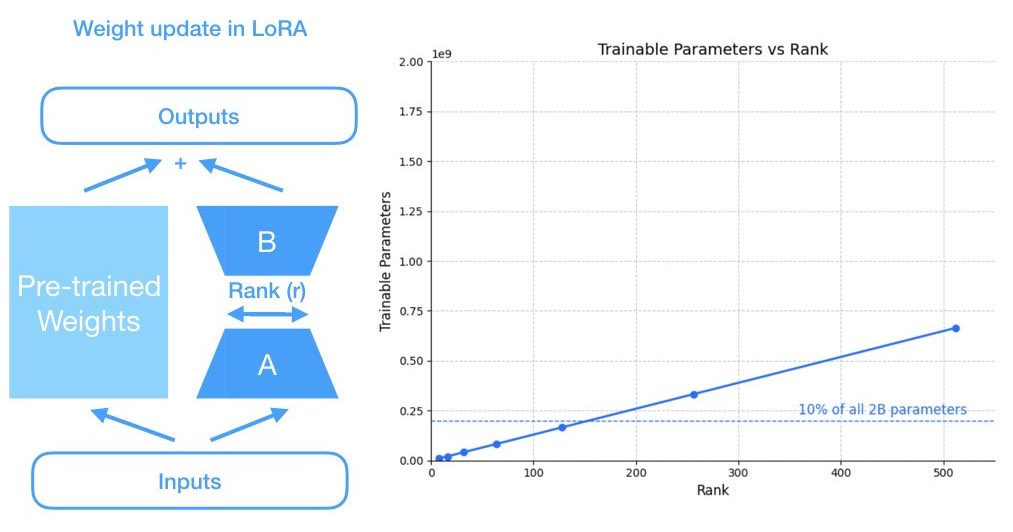

- `lora_alpha` is the scaling factor for the LoRA matrices' contribution.
  Higher values can increase accuracy and speed up convergence but risk overfitting.
  Lower values may require more training steps.
  Recommended values are usually `r` or `2r` [3,6] (see [Experimentation and hyperparameter tuning](#Experimentation-and-hyperparameter-tuning)).
- `lora_dropout` is the probability of zeroing out elements in low-rank matrices for regularization. This can reduce overfitting slightly but is usually set to 0 for faster training. (see [Experimentation and hyperparameter tuning](#Experimentation-and-hyperparameter-tuning)).
- `bias`: Leave this as the default value of 0 for faster and less over-fit training.
- `use_gradient_check pointing`: We leave this as the default value of `"unsloth"` since it reduces memory usage by an extra 30%.
- For now, we are not using the advanced features of rank stabilized LoRA (rsLoRA) and LoftQ.

Note, that the choice of hyperparameters is discussed in the [Experimentation and hyperparameter tuning](#Experimentation-and-hyperparameter-tuning) section.

In [ ]:
# Do model patching and add fast LoRA weights
model = FastLanguageModel.get_peft_model(
    model,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    r = 256,          # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    lora_alpha = 512, # Recommended to set to r or 2r
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # Rank stabilized LoRA
    loftq_config = None, # LoftQ
)

## Step 4: Define Training Arguments

Next, we need to define the training parameters and hyperparameters.

- `per_device_train_batch_size` and `gradient_accumulation_steps` are the parameters that determine the effective batch size when using gradient accumulation. Although we have two T4 GPUs available in this Kaggle notebook environment, Unsloth currently doesn't support multi-GPU training ([only available in beta for community members](https://github.com/unslothai/unsloth/issues/859)). That means that we only have the memory of one T4 available during training (`number_of_devices = 1`). Therefore, this training pipeline uses gradient accumulation to save memory. Larger batch sizes generally lead to smoother training (more stable gradient estimates) and can improve training speed, but they also require more memory.
The effective batch size with gradient accumulation is calculated as [2]:
> `per_device_train_batch_size * gradient_accumulation_steps * number_of_devices`

    - `per_device_train_batch_size`: Can be increased to utilize the memory of your GPU more, but it is not recommended since it can make training slower due to padding issues. Although experimentation showed that higher batch sizes (e.g., 128) would fit into memory of a T4, we decide to stay with a fairly low value of 4.
    - `gradient_accumulation_steps`: The number of training steps after which the model weights are updated. Recommended to increase this instead of `per_device_train_batch_size` when you want to increase the virtual batch size since it does not impact memory consumption. We decide to set it to 16 to simulate a fairly large batch size of 64 for a trade-off between smoother training curves, training speed, and convergence.

<div class="alert alert-block alert-info">
    <h3>What is gradient accumulation?</h3>
    <strong>Gradient accumulation</strong> is a technique to simulate a larger batch size than the hardware's memory can handle during training. 
    If the hardware's memory is only able to handle micro-batches (e.g., 1), the gradient updates will be noisy when we train the model.
    Instead of updating the model weights after each batch, gradient accumulation collects gradients (usually summed or averaged) over several micro-batches and applies the update only after a specified number of training steps. 
    This allows training with larger effective batch sizes, which can improve model performance and stability, even on GPUs with limited memory. 
    See <a href="https://lightning.ai/blog/gradient-accumulation/" target="_blank">Gradient accumulation</a> for more information.
</div>

- `num_train_epochs`: A training epoch is a full pass over the training dataset. While training neural network models from scratch and traditional fine-tuning is done over multiple epochs, fine-tuning LLMs doesn't require multiple epochs [4]. Instead, one to a maximum of three epochs is recommended to avoid overfitting [4, 5]. Alternatively, for testing purposes, you can replace `num_train_epochs` with `max_steps` (e.g., `max_steps = 60`) to run the training pipeline over a smaller set of samples (number of data samples = `max_steps` * `effective_batch_size` [2]). *Since we are using a medium-sized dataset, we decide to train the model for only 1 epoch.*
- `learning_rate`: Reduce the learning rate if you want to make the fine-tuning process slower, but also converge to a higher accuracy result most likely. Recommended values are usually [2e-4, 1e-4, 5e-5, 2e-5]. (see [Experimentation and hyperparameter tuning](#Experimentation-and-hyperparameter-tuning)).
- `lr_scheduler_type`: Adjusts the learning rate for smoother learning rate decay, preventing abrupt model parameter changes. Recommended values are `cosine` or `linear`, although it has been reported that the choice may not have a big impact on `adamw` and `adam` optimizer [4]. (see [Experimentation and hyperparameter tuning](#Experimentation-and-hyperparameter-tuning)).
- `report_to`: For experiment tracking, this notebook uses W&B. Note, for W&B, no need to specifically log each hyperparameter. They will be logged automatically.

In [ ]:
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

training_args = TrainingArguments(
    per_device_train_batch_size = 4,     # batch size per device during training
    gradient_accumulation_steps = 16,    # number of steps before performing a backward/update pass
    # for partial training runs
    #max_steps = 16,
    #warmup_steps = 5,
    num_train_epochs = 1,                # number of training epochs
    warmup_ratio = 0.03,                 # warmup ratio based on QLoRA paper
    fp16 = not is_bfloat16_supported(),
    bf16 = is_bfloat16_supported(),
    optim = "adamw_8bit",                # Optimizer
    learning_rate=2e-4,                  # learning rate, based on QLoRA paper
    weight_decay = 0.01,                 # Weight decay
    lr_scheduler_type = "linear",        # Learning rate scheduler
    seed = 3407,
    output_dir = "outputs",              # Directory to save
    eval_strategy = "steps",             # Evaluate after a certain number of steps
    logging_steps = 16,                   # Log metrics
    report_to = "wandb",                 # Logging to W&B dashboard
),

## Step 5: Training Setup

Once the adapters are attached, you can use the model directly within any class from the Hugging Face ecosystem.
We will use the `SFTTrainer` from Huggingface's `trl`, which supports a native integration with PEFT (including LoRA and QLoRA) to fine-tune the model.

The SFTTrainer makes it straightfoward to supervise fine-tune open LLMs. 
We now have every building block we need to create our `SFTTrainer` to start then training our model.

In [ ]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_ds,     # Training dataset
    eval_dataset = valid_ds,      # Evaluation dataset
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    output_dir = "outputs",              
    args = training_args,
)

In [ ]:
import torch

#@title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

# Experimentation and hyperparameter tuning

After building out the baseline and evaluation pipeline, we start running experiments to find the optimal set of key hyperparameters.
First, make sure to start a new W&B run before you begin training the model to track relevant training information.
Then, you can start fine-tuning the model by calling the `train()` method on the `Trainer` instance. 
This will start the training loop and train our model for the defined number of epochs. 

You can find the related W&B dashboard here for details and additional experiments: https://wandb.ai/iamleonie/gemma_finetune 

The goal of experimentation is to determine a set of hyperparameters so that the training loss gets as small as possible (for datasets of 10,000 to 100,000 samples, aim for a loss between 1 and 0.5).

In [ ]:
import wandb

# Log in to W&B
wandb.login(key=wandb_key)

# Start a new run
with wandb.init(project="gemma_finetune") as run:
    
    # Start training (fine-tuning) the model 
    trainer_stats = trainer.train()

    # Enable this code to track validation metrics during training
    if False:
        FastLanguageModel.for_inference(model) # Change model to inference mode
        metric = evaluate_model_performance(pd.DataFrame(dataset['valid']), alpaca_prompt, model)
        wandb.log({"acc": metric[0]})
        wandb.log({"bleu": metric[1]})

In [ ]:
#@title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory         /max_memory*100, 3)
lora_percentage = round(used_memory_for_lora/max_memory*100, 3)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

*Note: The following experiments were run on roughly 15,000 samples. Additionally, attentive readers will notice that the training and validation loss curves are at a higher level in the experiments below than in the final training run. During development, we noticed that the used prompt (wording and language) can strongly impact the loss curves while the validation metrics stayed the same. The final model was tuned with a different prompt than the experiments shown below.*

## LoRA Hyperparameters

First, we begin by tuning the most impactful parameters for resource usage and model quality, which are the LoRA rank `r` and the scaling factor `lora_alpha`.

The experiments for `r` show:
- training and validation loss decrease with higher `r`
- validation metrics increase with higher `r` (only accuracy available here because BLEU was added later)

As the validation loss decreases in proportion to the training loss - even for higher `r`, we decide to select the highest **`r` of 256**.

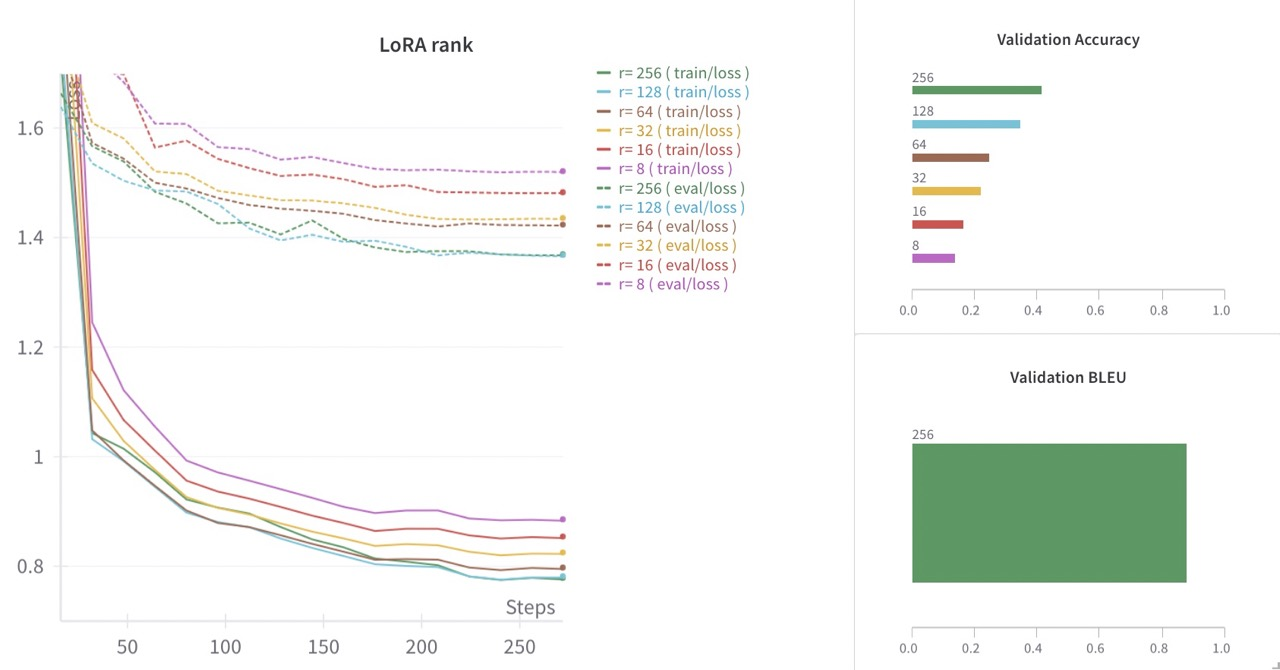

Next, the experiments for `lora_alpha` show:
- training and validation loss decrease with higher `lora_alpha`
- validation metrics increase with higher `lora_alpha`
- As suggested in [3,5] `lora_alpha = r` and `lora_alpha = 2 * r` achieve the best training and validation loss and validation metric values.

As the validation loss decreases in proportion to the training loss - even for higher `lora_alpha`, we decide to select the highest **`lora_alpha = 2 * r` of 512**. 

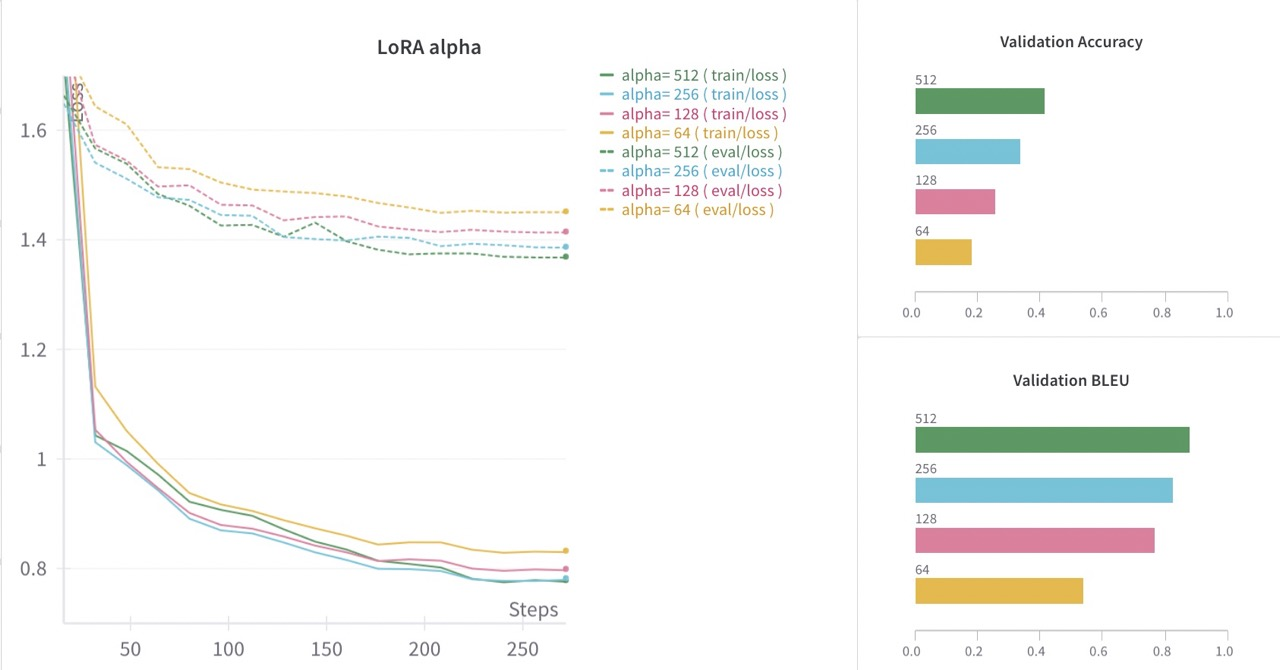
   
## Learning Rate and learning rate scheduler

The next most impactful parameters on model quality are the learning parameters.

The experiments for `learning_rate` show:
- training and validation loss decrease with higher `learning_rate`
- validation metrics increase with higher `learning_rate`

As the validation loss decreases in proportion to the training loss, we decide to select the highest **`learning_rate` of 2e-4**.

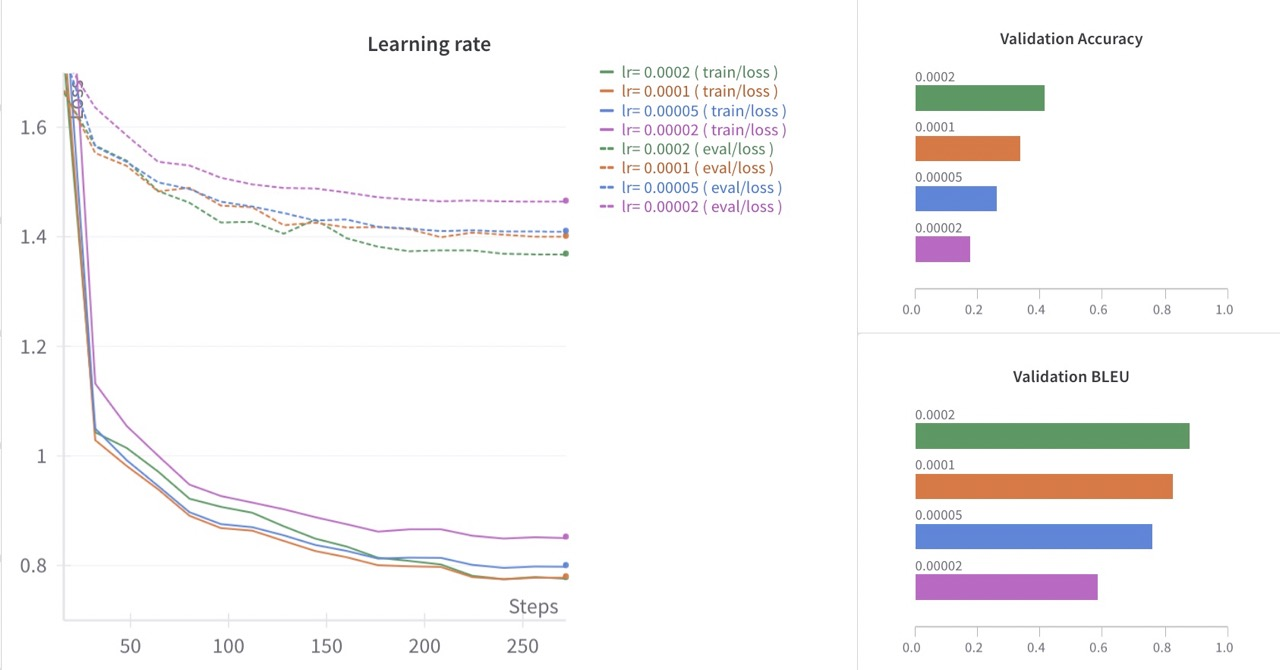

The experiments for `lr_scheduler` show that as suggested in [5], the difference between `cosine` and `linear` schedulers is only small since we are using an AdamW optimizer. As the loss curves are slightly lower and the validation metrics are slightly higher for `linear`, we select it as the learning rate scheduler.
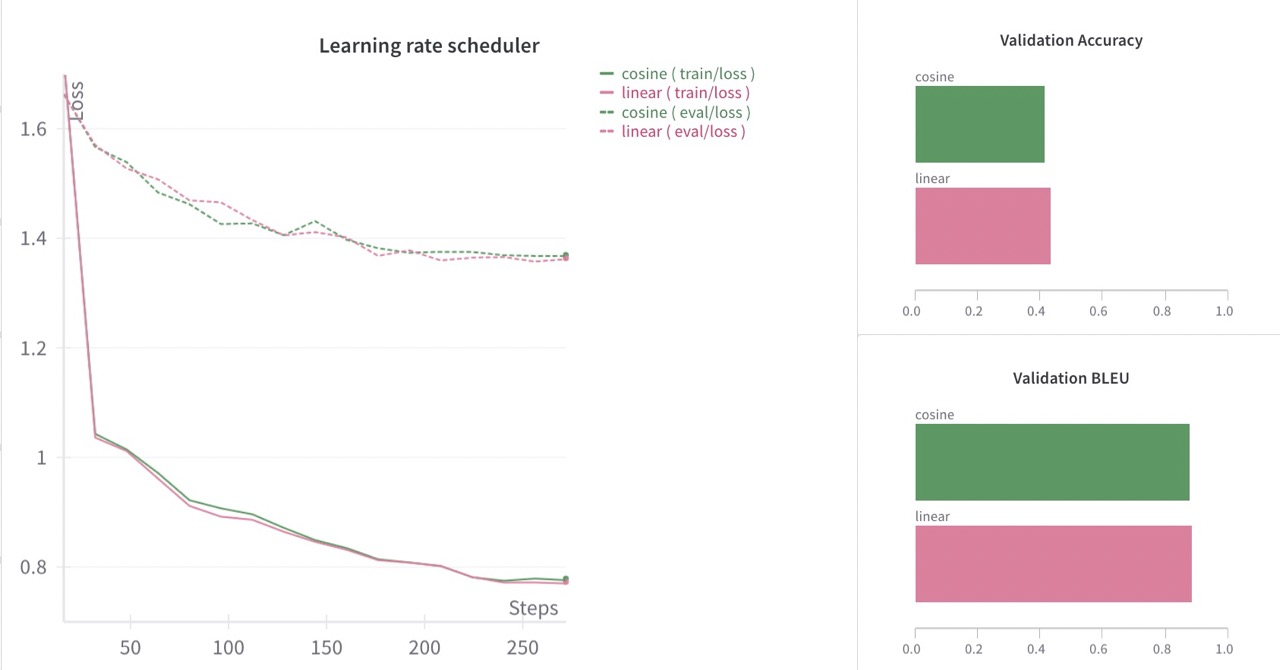

## Regularization
Lastly, we can check regularization techniques, such as using LoRA dropout (`lora_dropout`), using smaller weight decay (`weight_decay`) or modifying gradient clipping values (`max_grad_norm`) to address overfitting or instability. Although you can see that varied values of `weight_decay` and `max_grad_norm` lead to decreased validation loss at similar training loss, we decide not to change these values as the validation metrics decrease in comparison to the baseline.

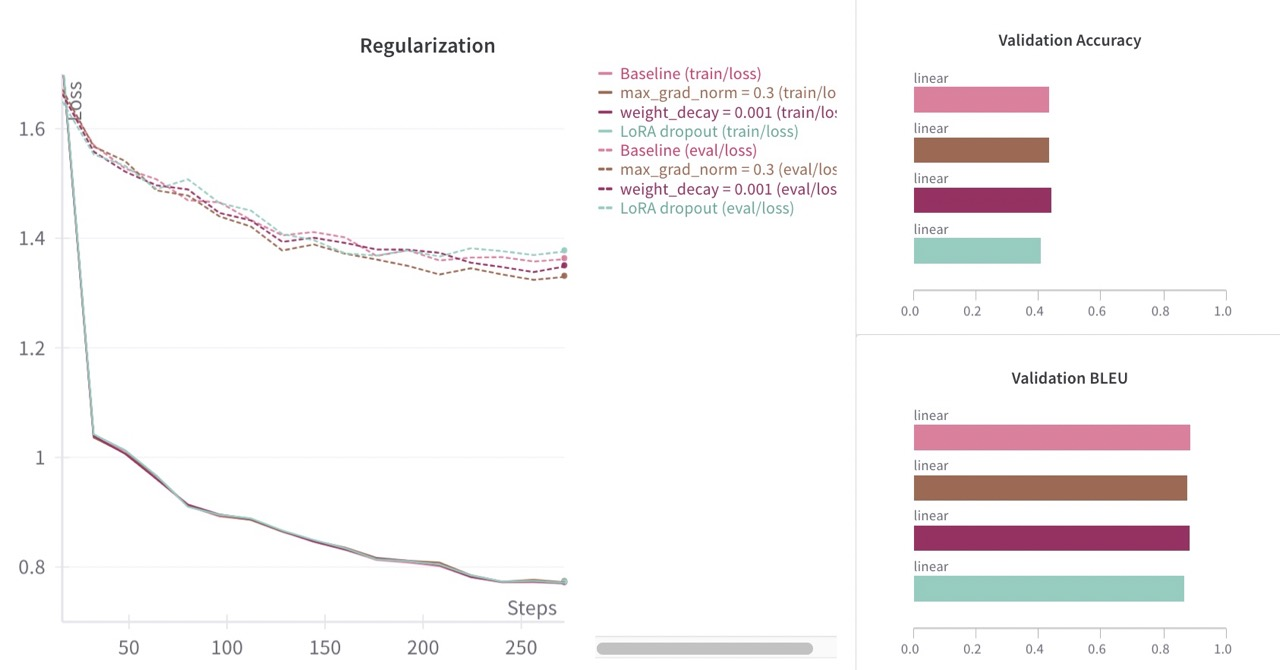

After the training run is finished, we can save the model. Note that we are only saving the adapted model weights instead of the full model because we are using a PEFT method. 

In [ ]:
# Save trained model and tokenizer
model_output_folder = "gemma_2_2b_jpn_yomigana_it"

trainer.save_model(f"{output_dir}/{model_output_folder}")
tokenizer.save_pretrained(f"{output_dir}/{model_output_folder}")

# Publish the model
Lastly, we will upload the fine-tuned model to Kaggle Models and the Hugging Face hub and make it available for public use.

We first use the `kagglehub` library to publish the fine-tuned [Gemma 2 2b JPN Yomigana IT](https://www.kaggle.com/models/iamleonie/gemma-2-2b-jpn-yomigana-it/transformers/default) model as a Kaggle Model with the Gemma license. Upon uploading a new model card will be created if one doesn't exist yet; otherwise, a new version will be added to the existing model.

In [ ]:
kaggle_username = kagglehub.whoami()["username"]

# The handle must follow this pattern '<KAGGLE_USERNAME>/<MODEL>/<FRAMEWORK>/<VARIATION>'
handle = f"{kaggle_username}/gemma-2-2b-jpn-yomigana-it/transformers/default"
local_model_dir = f"{output_dir}/{model_output_folder}"

kagglehub.model_upload(handle, local_model_dir, 'Gemma', version_notes=run.name)

Since the Gemma model family is available on both Kaggle and Hugging Face, we will also upload the fine-tuned model to Hugging Face.

In [ ]:
model.push_to_hub("iamleonie/gemma-2-2b-jpn-yomigana-it", 
                  tokenizer,
                  token = hf_token,
                  commit_message=run.name)

# Inference and Evaluation of Fine-Tuned LLM

To run inference and evaluate the fine-tuned LLM, you first need to load the model as you did with the base model. Here, we are using Unsloth for faster inference but you can also use Transformers, as showcased in this [example notebook](https://www.kaggle.com/code/iamleonie/example-use-with-transformers). When using Transformers, you need to load the base model with the original weights first and then the LoRA adapters. With Unsloth, you only need to specify the LoRA adapters path and the base model will be loaded automatically.

In [ ]:
# Download the model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "/kaggle/input/gemma-2-2b-jpn-yomigana-it/transformers/default/11",
    max_seq_length = max_seq_length,
    dtype = None, # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
    load_in_4bit = True, # Use 4bit quantization to reduce memory usage.
    token = hf_token, # not needed when downloading from kaggle models but needed for donwloading finetuned model
)

FastLanguageModel.for_inference(model) # Unsloth has 2x faster inference!

To run inference, you need to put the model into inference mode. Then, you can infer it as shown below. The model correctly outputs "せみのこえ", which is the Yomigana for "蝉の声".

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

alpaca_prompt = """以下は、タスクを説明する指示と、さらに文脈を提供する入力がペアになったものです。リクエストを適切に完了する回答を書いてください。

### 指示:
以下の入力を読み仮名に書き換えてください。

### 入力:
{}

### 回答:
{}
"""

input_ids = tokenizer(
[
    alpaca_prompt.format(
        "蝉の声", # input
        "", # output - leave this blank for generation!
    )
], return_tensors = "pt").to(device)

outputs = model.generate(**input_ids, max_new_tokens = 64, use_cache = True, )
# print(tokenizer.decode(outputs[0]))

generated_text = tokenizer.batch_decode(outputs[:, input_ids['input_ids'].shape[1]:], skip_special_tokens=True)[0]
print(generated_text.strip())

The fine-tuned model is evaluated on the test dataset, we used in [How to evaluate an LLM for Yomigana Transcription](#How-to-evaluate-an-LLM-for-Yomigana-Transcription). You can see the full evaluation code in this notebook: [Evaluating Gemma 2 JPN for Yomigana Generation](https://www.kaggle.com/code/iamleonie/evaluating-gemma-2-jpn-for-yomigana-generation).

As you can see below, we were able to increase the level of performance of Gemma 2 JPN IT in comparison to zero-shot and few-shot prompting.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_mecab = pd.read_csv('/kaggle/input/evaluating-gemma-2-jpn-for-yomigana-generation/mecab_benchmark.csv')
[mecab_accuracy, mecab_bleu] = evaluate_model_performance(df_mecab)

metrics = []
df_zero_shot = pd.read_csv('/kaggle/input/evaluating-gemma-2-jpn-for-yomigana-generation/zero-shot.csv')
df_zero_shot.fillna('', inplace=True)
metrics.append(evaluate_model_performance(df_zero_shot))

df_few_shot = pd.read_csv('/kaggle/input/evaluating-gemma-2-jpn-for-yomigana-generation/few-shot.csv')
df_few_shot.fillna('', inplace=True)
metrics.append(evaluate_model_performance(df_few_shot))

df_fine_tune = pd.read_csv('/kaggle/input/evaluating-gemma-2-jpn-for-yomigana-generation/fine-tuned.csv')
df_fine_tune.fillna('', inplace=True)
metrics.append(evaluate_model_performance(df_fine_tune))

# Benchmark BLEU score if the text was not transcribed at all
bleu_baseline = df_zero_shot.apply(lambda x: sentence_bleu([list(x.Yomigana)], list(x.Japanese_text)), axis=1).mean()

# Data
labels = ['Zero-shot\nprompting', 'Few-shot\nprompting', 'Fine-tuning']
colors = ['lightgrey', 'lightgrey', '#076EFF' ]
# Parameters for bar plots
x = np.arange(len(labels))  # X positions for groups
width = 0.35  # Width of bars

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot 1: Accuracy
bars1 = ax1.bar(x, np.array(metrics)[:,0], width, color=colors, label='Accuracy')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.axhline(y=mecab_accuracy, color='#438EFC', linestyle='--', linewidth=1)  # Horizontal line
ax1.text(-0.2, mecab_accuracy, f'MeCab benchmark ({mecab_accuracy:.2f})', color='#438EFC', fontsize=12, ha='left', va='bottom')  # Annotation

ax1.set_ylim(0, 1)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlabel('Alignment Technique', fontsize=14)
ax1.set_ylabel('Accuracy', fontsize=14)
ax1.set_title('Accuracy\nfor Different Alignment Techniques\n', fontsize=16)
ax1.tick_params(axis='x', labelsize=12)

# Annotate bars with values
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x()+0.2, height, f'{height:.2f}', ha='center', va='bottom', color=colors[i], fontsize=12)
    
# Plot 2: BLEU score
bars2 = ax2.bar(x, np.array(metrics)[:,1], width, color=colors)

ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.axhline(y=mecab_bleu, color='#438EFC', linestyle='--', linewidth=1)  # Horizontal line
ax2.text(-0.2, mecab_bleu, f'MeCab benchmark ({mecab_bleu:.2f})', color='#438EFC', fontsize=12, ha='left', va='bottom')  # Annotation

ax2.axhline(y=bleu_baseline, color='#438EFC', linestyle='--', linewidth=1)  # Horizontal line
ax2.text(-0.2, bleu_baseline, f'Baseline ({bleu_baseline:.2f})', color='#438EFC', fontsize=12, ha='left', va='bottom')  # Annotation

ax2.set_ylim(0, 1)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlabel('Alignment Technique', fontsize=14)
ax2.set_ylabel('BLEU score', fontsize=14)
ax2.set_title('BLEU Score\nfor Different Alignment Techniques\n', fontsize=16)
ax2.tick_params(axis='x', labelsize=12)


# Annotate bars with values
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x()+0.2, height, f'{height:.2f}', ha='center', va='bottom', color=colors[i], fontsize=12)


# Adjust layout and show plot
plt.tight_layout()
plt.show()

del df_mecab, df_zero_shot, df_few_shot, df_fine_tune

Now, you can test the fine-tuned model by replacing "蝉の声" with any Japanese input to see how robust it is to additional inputs.
Or you can fork the [Example Use notebook of Gemma 2 JPN Yomigana IT](https://www.kaggle.com/code/iamleonie/example-use-with-transformers) and play around with it.

In [ ]:
inputs = tokenizer(
[
    alpaca_prompt.format(
        "蝉の声", # input
        "", # output - leave this blank for generation!
    )
], return_tensors = "pt").to("cuda")

outputs = model.generate(**inputs, max_new_tokens = 64, use_cache = True)
generated_text = tokenizer.batch_decode(outputs[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0]
print(generated_text.strip())

# Discussion

Finally, let's discuss some open questions, such as the cost of fine-tuning and limitations and further improvements of the model.

## How expensive is it to fine-tune an LLM?
This notebook showcases how accessible and efficient LLM fine-tuning is with LoRA and Unsloth. This LoRA fine-tuning pipeline can be run in environments like Kaggle notebooks or Google Colab. Both environments allow developers and researchers to achieve meaningful results without incurring any upfront costs by leveraging the free GPU quotas.

For more extensive experimentation or access to more powerful GPUs like the NVIDIA A100, upgrading to a paid option is still cost-effective. For example, to fine-tune this variant of Gemma 2, I purchased 200 computation units for approximately \$20 for Google Colab. The final fine-tuning process took **3 hours of training time** on an NVIDIA A100 GPU, which costs 8.47 computation units per hour. That means, the **training cost of the final model is about $2.5**. 

## Limitations and further improvements
As you can see in the [Inference and Evaluation](#Inference-and-Evaluation) section, the resulting fine-tuned `gemma-2-jpn-yomigana-it` model still has some limitations. Although, we showed that the fine-tuned model outperforms the MeCab benchmark, it does generate wrong answers occasionally.

Here are some suggestions to further improve the model's limitations:
- **Extended experimentation with regularization techniques:** During [Experimetantion and hyperparameter tuning](#Experimentation-and-hyperparameter-tuning) we decided not to further include regularization techniques. However, extended experimentation with hyperparameters, such as `max_grad_norm`, `weight_decay`, and `lora_dropout` could lead to improved performance.
- **Use of Rank-Stabilized LoRA (rsLoRA):** Furthermore, we determined a fairly high value for the adapter ranks `r` during [Experimentation and hyperparameter tuning](#Experimentation-and-hyperparameter-tuning). To stabilize learning for higher adapter ranks and for improved fine-tuning performance, you could experiment with Rank-Stabilized LoRA (rsLoRA), which modifies the scaling factor of LoRA adapters to be proportional to $1/√r$ (instead of 1/r).
- **Change to conversational style:** During the fine-tuning process, the model lost its conversational capabilities due to its focus on a single instruction. If you'd like to fine-tune the model to be able to convert Japanese text to Yomigana in a multi-turn conversational style, you'd need to adjust the dataset style to a conversational format and chose a more conservative set of hyperparameters.

# Summary

This tutorial showcased **how to fine-tune an LLM like Gemma 2 on your own custom dataset using LoRA**.
The goal of fine-tuning Gemma 2 was to improve its performance for **transcribing common Japanese text into its corresponding Yomigana (reading aid)** to help students of any level learn reading Japanese.

By using the Unsloth library, we were able to fine-tune a variant of Gemma 2 with a model size of 2 billion parameters **within a free Kaggle Notebook environment using only a single T4 GPU with 16GB memory.** This shows that fine-tuning LLMs with a PEFT technique and optimized operations doesn't require large computational resources.

The resulting fine-tuned [Gemma 2 JPN Yomigana IT](https://www.kaggle.com/models/iamleonie/gemma-2-2b-jpn-yomigana-it) model outperforms the available rule-based MeCab solution for Yomigana generation in terms of both accuracy and BLEU score:

| Yomigana Solution   | Accuracy | BLEU score |
|----------|----------|------------|
| MeCab    |  0.762   |   0.919    |
| [Gemma 2 JPN Yomigana IT](https://www.kaggle.com/models/iamleonie/gemma-2-2b-jpn-yomigana-it)    |   0.841  |       0.945     |


# Related artifacts
* Training and evaluation dataset:
    * [Post-processed Hurigana Corpus Shosi dataset](https://www.kaggle.com/datasets/iamleonie/huriganacorpus-shosi-dataset)
    * [Notebook for dataset generation](https://www.kaggle.com/code/iamleonie/generation-of-hurigana-corpus-shosi-dataset)
* Fine-tuned model:
    * [Gemma 2 JPN Yomigana IT](https://www.kaggle.com/models/iamleonie/gemma-2-2b-jpn-yomigana-it)
    * [Notebook for example use of model with Transformers](https://www.kaggle.com/code/iamleonie/example-use-of-gemma-2-2b-jpn-yomigana-it/)
* Experiment tracking: [W&B Dashboard](https://wandb.ai/iamleonie/gemma_finetune)
* **Fine-tuning pipeline: this Kaggle notebook**
* Evaluation notebook: [Evaluating Gemma 2 JPN for Yomigana Generation
](https://www.kaggle.com/code/iamleonie/evaluating-gemma-2-jpn-for-yomigana-generation)
  
# References

[1] Labonne, M. (2024). [Fine-tune LLAMA-3.1 ultra efficiently with Unsloth](https://towardsdatascience.com/fine-tune-llama-3-1-ultra-efficiently-with-unsloth-7196c7165bab). Towards Data Science. Retrieved January 14, 2025.

[2] Nodematic Tutorials. (2024). [Fine-tuning walkthrough](https://www.youtube.com/watch?v=EE-nEecm3Wo) Video. Retrieved January 14, 2025.

[3] Ogiso, N. (2014). Keitaisokaiseki: Morphological analysis. In M. Yamazaki (Ed.), Kouza Nihongo Koopasu: Kakikotoba Koopasu: Sekkei to Koutsiku. Series of Japanese corpus, Vol. 2, Written language corpus: Design and construction (pp. 89–115). Tokyo: Asakura Shoten.

[4] Raschka, S. (n.d.). [Practical tips for fine-tuning LLMs](https://magazine.sebastianraschka.com/p/practical-tips-for-finetuning-llms). Retrieved January 14, 2025.

[5] Reddit. (2024). [Why do most tutorials do instruction tuning of base model instead of instruction-tuned models?](https://www.reddit.com/r/LocalLLaMA/comments/19e0a2y/why_do_most_tutorials_do_instruction_tuning_of/) Reddit post. Retrieved January 14, 2025.

[6] Schmid, P. (2024). [How to Fine-Tune LLMs in 2024 with Hugging Face](https://www.philschmid.de/fine-tune-llms-in-2024-with-trl). Retrieved January 14, 2025.

[7] Unsloth. (2025). [Unsloth documentation](https://docs.unsloth.ai/). Retrieved January 14, 2025.